# Creating Embeddings in Medication Features

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.pyplot import title
import seaborn as sns

from pathlib import Path
import random

import tensorflow as tf
import keras


SEED = 42

In [2]:
# should be >= 3.0.0
keras.__version__

'3.14.1'

In [3]:
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)

In [4]:
root = Path.cwd().parent.parent
print(root)

/Users/vtsoumpris/PycharmProjects/ds207_final_project


### Importing Data

#### Reading Train Data

In [5]:
# x train
dataset_path_Xtrain = \
    root / 'data' / 'interim' / 'splitted' / 'X_train_mini.csv'
# y train
dataset_path_Ytrain = \
    root / 'data' / 'interim' / 'splitted' / 'y_train_mini.csv'
# read csv
x_train = pd.read_csv(dataset_path_Xtrain)
y_train = pd.read_csv(dataset_path_Ytrain)
df_train = pd.concat([x_train, y_train], axis = "columns")
# rows and columns
print("The dataset contains ", df_train.shape[0], " rows and ", df_train.shape[1], " features.")
df_train.head()

The dataset contains  65129  rows and  50  features.


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,146463126,23312916,AfricanAmerican,Female,[40-50),?,1,3,5,8,...,No,Steady,No,No,No,No,No,No,Yes,NO
1,42768240,888327,Caucasian,Female,[60-70),?,1,1,7,2,...,No,No,No,No,No,No,No,No,No,NO
2,288867768,45861579,Caucasian,Female,[60-70),?,2,1,7,13,...,No,Up,No,No,No,No,No,Ch,Yes,NO
3,79126704,383058,AfricanAmerican,Female,[70-80),?,1,1,7,5,...,No,No,No,No,No,No,No,No,Yes,>30
4,214896840,38385846,Caucasian,Male,[80-90),?,1,3,7,4,...,No,Down,No,No,No,No,No,Ch,Yes,<30


#### Reading Validation Data

In [6]:
root = Path.cwd().parent.parent
# x validation
dataset_path_Xval = \
    root / 'data' / 'interim' / 'splitted' / 'X_val.csv'
# y validation
dataset_path_Yval = \
    root / 'data' / 'interim' / 'splitted' / 'y_val.csv'
# read csv
x_val = pd.read_csv(dataset_path_Xval)
y_val = pd.read_csv(dataset_path_Yval)
df_val = pd.concat([x_val, y_val], axis = "columns")
# rows and columns
print("The dataset contains ", df_val.shape[0], " rows and ", df_val.shape[1], " features.")


The dataset contains  16283  rows and  50  features.


#### Filtering to Medication Features

In [7]:
x_train_m = x_train.loc[:, 'metformin': 'metformin-pioglitazone']
x_val_m = x_val.loc[:, 'metformin': 'metformin-pioglitazone']

print("Selected features:\n", x_train_m.columns.tolist())

Selected features:
 ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']


Extract Unique Values from all the Medication Features

In [8]:
def extract_feature_unique_values(df):
    unique_values = []
    for column in df.columns:
        unique_values.append(df[column].unique().tolist())
    return unique_values

def extract_total_unique_values(lists):
    result_list = \
    list(
        dict.fromkeys(item for sublist in lists for item in sublist)
    )
    return result_list

#################
# apply functions
unique_values = \
extract_total_unique_values(
    extract_feature_unique_values(x_train_m)
)

print("Unique values that could exist in any of the medication features (based on train set):\n",
      unique_values)

Unique values that could exist in any of the medication features (based on train set):
 ['No', 'Up', 'Steady', 'Down']


#### StringLookup Layer to encode categories

In [9]:
# initialise StringLookup layer
str_lookup_layer = keras.layers.StringLookup()
# adapt the layer to the unique values
str_lookup_layer.adapt(list(unique_values))

# checking the output
str_lookup_layer([
    ['No'], ['Up'], ['Steady'], ['Down']
]).numpy().tolist()
#onehot_layer =  layers.CategoryEncoding(num_tokens=len(unique_values))
#onehot_layer(unique_values)

[[3], [1], [2], [4]]

#### Combining  StringLookup layer with Embedding layer

In [10]:
def create_embedding_layer(unique_values,
                           embedding_dim= 10,
                           seed = 42):
    """
    Create and return a sequential embedding layer that transforms string inputs
    into dense embeddings. The function creates a mapping of string values to
    numerical indices using a StringLookup layer and applies an embedding transformation.

    :param unique_values: List of unique string values to map.
    :type unique_values: list[str]
    :param embedding_dim: The dimensionality of the embedding output space.
    :type embedding_dim: int, optional
    :return: A keras sequential layer combining StringLookup and Embedding.
    :rtype: keras.Sequential
    """

    # ensuring stable vocabulary order
    # for reproducibility
    unique_values = list(unique_values)

    str_lookup_layer = keras.layers.StringLookup(
        vocabulary=unique_values
    )
    # adapt the layer to the unique values
    #str_lookup_layer.adapt(unique_values)
    # create a pipeline of the two layers
    look_up_and_embed = keras.Sequential([
        # 1st: StringLookup layer
        str_lookup_layer,
        # 2nd: Embedding layer
        # with input_dim = vocabulary size of StringLookup layer,
        # and output_dim = embedding dimension
        keras.layers.Embedding(
            input_dim= str_lookup_layer.vocabulary_size(),
            output_dim= embedding_dim,
            # ensuring stable embeddings for reproducibility
            embeddings_initializer= keras.initializers.RandomUniform(seed= seed)
        )
    ])
    # return the layer
    return look_up_and_embed


In [11]:
lue = create_embedding_layer(unique_values,
                             embedding_dim= 5,
                             seed = SEED)
# create embeddings
lue(
    np.array([['No'], ['Up'], ['Steady'], ['Down']])
)

<tf.Tensor: shape=(4, 1, 5), dtype=float32, numpy=
array([[[ 0.01265594,  0.02549983, -0.03267942, -0.03712874,
         -0.04473295]],

       [[ 0.04425292, -0.02695481, -0.00224584, -0.02534449,
          0.0224576 ]],

       [[ 0.02690658,  0.00369109, -0.03312949,  0.00028085,
         -0.03000574]],

       [[-0.04647031, -0.01872196, -0.00256057,  0.00597994,
          0.03235373]]], dtype=float32)>

#### Sample Preprocessing and Modelling

In [12]:
def encode_readmitted(y):
    """
    Encodes the 'readmitted' column in a given DataFrame using a predefined mapping.

    The function maps values in the 'readmitted' column to numeric representations:
    'NO' is mapped to 0, '>30' is mapped to 1, and '<30' is mapped to 2. The mapping
    is applied to a copy of the input DataFrame to preserve immutability of the original
    data.

    :param y: A pandas DataFrame containing a 'readmitted' column with categorical values
        to be encoded. The column must contain only the keys supported by the mapping
        dictionary.
    :return: A new pandas DataFrame with the 'readmitted' column encoded as integers
        based on the predefined mapping.
    """
    mapping = {'NO': 0, '>30': 1, '<30': 1}

    y_encoded = y.copy()
    y_encoded['readmitted'] = y_encoded['readmitted'].map(mapping)

    return y_encoded

In [13]:
def convert_to_tf_tensor(X ,y):
    """
    Converts input data and labels into TensorFlow tensors for further processing.

    This function processes the provided input data `X` and labels `y` by converting
    them into TensorFlow tensors. It ensures that missing values in `X` are replaced
    with the string 'Unknown', and converts all values in `X` to strings. For `y`,
    the 'readmitted' column is converted to integer values of type int32. Finally,
    the function prints the datatype and shape of the resulting tensors.

    :param X: The input DataFrame to be processed and converted into a TensorFlow
              tensor. Missing values are replaced with 'Unknown', and all data is
              converted to strings.
    :type X: pandas.DataFrame
    :param y: The labels DataFrame containing the 'readmitted' column, which will
              be converted to a TensorFlow tensor of integers.
    :type y: pandas.DataFrame
    :return: A tuple containing two TensorFlow tensors: the processed tensor for `X`
             and the corresponding tensor for `y`.
    :rtype: tuple[tf.Tensor, tf.Tensor]
    """
    x_tf = tf.convert_to_tensor(
        X.fillna('Unknown').astype(str).values,
        dtype=tf.string
    )

    y_tf = tf.convert_to_tensor(
        y['readmitted'].astype('int32').values,
        dtype=tf.int32
    )

    print(x_tf.dtype,
          y_tf.dtype,
          x_tf.shape,
          y_tf.shape)

    return x_tf, y_tf

#### Preprocess of Data

In [14]:
num_features = len(x_train_m.columns.tolist())
print("Number of features to input: ",num_features)

Number of features to input:  23


In [15]:
y_train_encoded = encode_readmitted(y_train[['readmitted']])
y_val_encoded = encode_readmitted(y_val[['readmitted']])

In [16]:
xtf_tr, ytf_tr = convert_to_tf_tensor(X = x_train_m, y=y_train_encoded)
xtf_vl, ytf_vl = convert_to_tf_tensor(X = x_val_m, y=y_val_encoded)

<dtype: 'string'> <dtype: 'int32'> (65129, 23) (65129,)
<dtype: 'string'> <dtype: 'int32'> (16283, 23) (16283,)


#### Draft model Architecture

In [17]:
tf.keras.backend.clear_session()
np.random.seed(SEED)
tf.random.set_seed(SEED)
he_normal_init = keras.initializers.HeNormal(seed=SEED)

# create input layer
cat_input = keras.layers.Input(shape=(num_features,), dtype='string')
# use the lookup + embedding layer to encode the medication categories
cat_embeddings = lue(cat_input)
# convert (batch, medication_feature, embedding_dim) to one vector per row
encoded_inputs = keras.layers.Flatten()(cat_embeddings)

### block 1
hidden_1 = keras.layers.Dense(256, activation='leaky_relu',
                              kernel_initializer= he_normal_init,
                              bias_initializer= keras.initializers.zeros()
                              )(encoded_inputs)
hidden_2 = keras.layers.Dense(128, activation='leaky_relu',
                              kernel_initializer= he_normal_init,
                              bias_initializer= keras.initializers.zeros()
                              )(hidden_1)
### block 2
hidden_3 = keras.layers.Dense(64, activation='gelu',
                              kernel_initializer= he_normal_init,
                              bias_initializer= keras.initializers.zeros()
                              )(encoded_inputs)
hidden_4 = keras.layers.Dense(32, activation='gelu',
                              kernel_initializer= he_normal_init,
                              bias_initializer= keras.initializers.zeros()
                              )(hidden_3)

####
# merge the two blocks/ concatenate branch representations
merged_layer = keras.layers.concatenate([hidden_2, hidden_4])
merged_layer = keras.layers.Dense(80, activation= "leaky_relu",
                                        kernel_initializer= he_normal_init,
                                         bias_initializer= keras.initializers.zeros()
                                       )(merged_layer)
## pre-final layer
hidden_5 = keras.layers.Dense(40, activation= "leaky_relu",
                                        kernel_initializer= he_normal_init,
                                         bias_initializer= keras.initializers.zeros()
                                       )(merged_layer)
## pre-final layer
hidden_6 = keras.layers.Dense(20, activation= "leaky_relu",
                                        kernel_initializer= he_normal_init,
                                         bias_initializer= keras.initializers.zeros()
                                       )(hidden_5)
# output
outputs = keras.layers.Dense(2,
                             activation='softmax',
                             kernel_initializer= keras.initializers.GlorotUniform(seed=SEED),
                             bias_initializer= keras.initializers.zeros()
                        )(hidden_6)

#### Compile Model

In [18]:
model = keras.Model(inputs= cat_input, outputs= outputs)
model.compile(
        optimizer= keras.optimizers.Adam( learning_rate= 0.00001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 23)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 23, 5)     │         25 │ input_layer[0][0] │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 115)       │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │     29,696 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      7,424 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │      2,080 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 160)       │          0 │ dense_1[0][0],    │
│ (Concatenate)       │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 80)        │     12,880 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 40)        │      3,240 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 20)        │        820 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 2)         │         42 │ dense_6[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 89,103 (348.06 KB)

 Trainable params: 89,103 (348.06 KB)

 Non-trainable params: 0 (0.00 B)

#### Train Model

In [22]:
num_epochs
history = model.fit(
    x = xtf_tr,
    y = ytf_tr,
    epochs= num_epochs,
    validation_data= [xtf_vl, ytf_vl],
    shuffle = False,
    batch_size = 64,
    verbose= 1 ,
)

Epoch 1/10
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5489 - loss: 0.6869 - val_accuracy: 0.5543 - val_loss: 0.6858
Epoch 2/10
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5492 - loss: 0.6868 - val_accuracy: 0.5543 - val_loss: 0.6857
Epoch 3/10
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5497 - loss: 0.6867 - val_accuracy: 0.5544 - val_loss: 0.6856
Epoch 4/10
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5498 - loss: 0.6867 - val_accuracy: 0.5546 - val_loss: 0.6856
Epoch 5/10
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5499 - loss: 0.6866 - val_accuracy: 0.5548 - val_loss: 0.6855
Epoch 6/10
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5499 - loss: 0.6866 - val_accuracy: 0.5549 - val_loss: 0.6855
Epoch 7/10
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5501 - loss: 0.6865 - val_accuracy: 0.5544 - val_loss: 0.6854
Epoch 8/10
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5503 - loss: 0.6865 - 

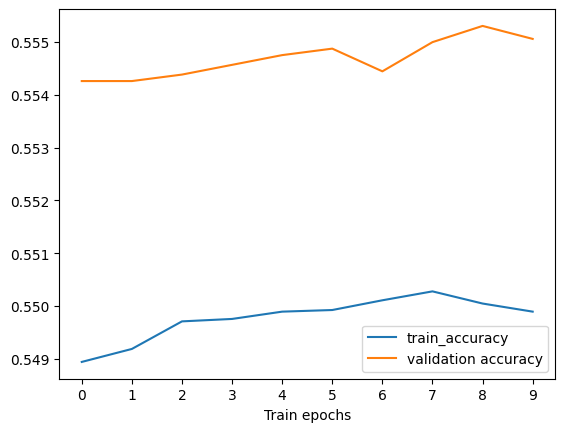

Training accuracy: 0.5499
Validation accuracy: 0.5551


In [23]:
# Retrieve the training metrics (after each train epoch) and the final validation
    # accuracy.
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
plt.plot(train_accuracy, label='train_accuracy')
plt.plot(val_accuracy, label='validation accuracy')
plt.xticks(range(num_epochs))
plt.xlabel('Train epochs')
plt.legend()
plt.show()

print('Training accuracy: %1.4f' %train_accuracy[-1])
print('Validation accuracy: %1.4f' %val_accuracy[-1])